aim: visualize and interpret the logistic regression model

In [ ]:
import nltk 
from os import getcwd 
import pandas as pd 
from nltk.corpus import twitter_samples 
import matplotlib.pyplot as plt 
import numpy as np 

In [13]:
# download dataset and import helpder functions 
from utils import process_tweet, build_freqs
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/suhuang/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [15]:
# load nltk sample dataset
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')
tweets = all_positive_tweets + all_negative_tweets
labels = np.append(np.ones((len(all_positive_tweets),1)), np.zeros((len(all_negative_tweets),1)), axis=0)

# split data into training set
train_pos = all_positive_tweets[:4000]
train_neg = all_negative_tweets[:4000]
train_x = train_pos + train_neg

print("number of tweets: ", len(train_x))

number of tweets:  8000


In [ ]:
# load extracted features from csv
data = pd.read_csv('./data/logistic_features.csv')
data.head(10)

,bias,positive,negative,sentiment
0,1.0,3020.0,61.0,1.0
1,1.0,3573.0,444.0,1.0
2,1.0,3005.0,115.0,1.0
3,1.0,2862.0,4.0,1.0
4,1.0,3119.0,225.0,1.0
5,1.0,2955.0,119.0,1.0
6,1.0,3934.0,538.0,1.0
7,1.0,3162.0,276.0,1.0
8,1.0,628.0,189.0,1.0
9,1.0,264.0,112.0,1.0


In [26]:
# save features as numpy array
X = data[['bias', 'positive', 'negative']].values 
Y = data['sentiment'].values

print(X.shape)
print(X)

(8000, 3)
[[1.000e+00 3.020e+03 6.100e+01]
 [1.000e+00 3.573e+03 4.440e+02]
 [1.000e+00 3.005e+03 1.150e+02]
 ...
 [1.000e+00 1.440e+02 7.830e+02]
 [1.000e+00 2.050e+02 3.890e+03]
 [1.000e+00 1.890e+02 3.974e+03]]


In [ ]:
# load pretrained logistic regression model 
theta = [6.03518871e-08, 5.38184972e-04, -5.58300168e-04]

Text(0, 0.5, 'negative')

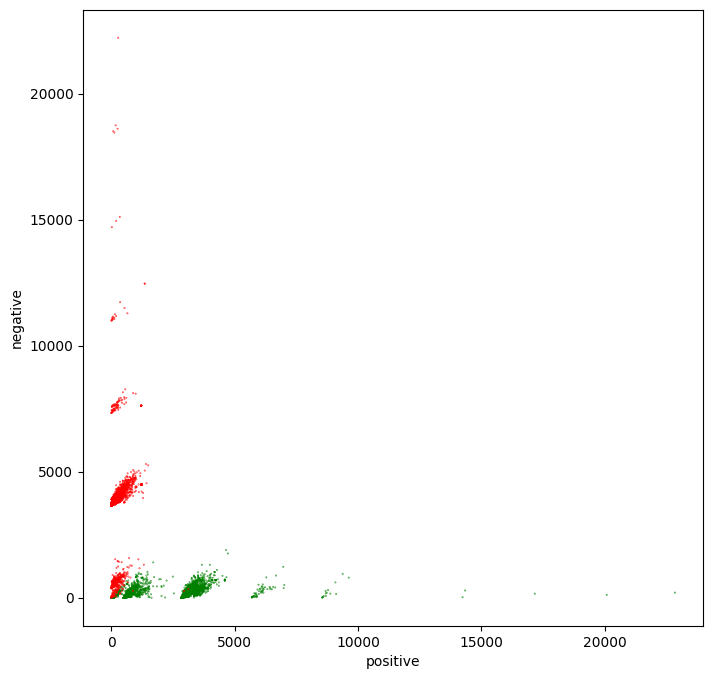

In [29]:
# plot each tweet using positive_sum and negative_sum 
fig, ax = plt.subplots(figsize=(8,8))
colours = ['red', 'green']

ax.scatter(X[:,1], X[:,2], c=[colours[int(k)] for k in Y], s=0.1)
plt.xlabel("positive")
plt.ylabel("negative")

In [31]:
# calculate decision boundary (separation line) and direction vector 
def neg(theta, pos): 
    return (-theta[0] - pos * theta[1]) / theta[2]

def direction(theta, pos): 
    return pos * theta[2] / theta[1]

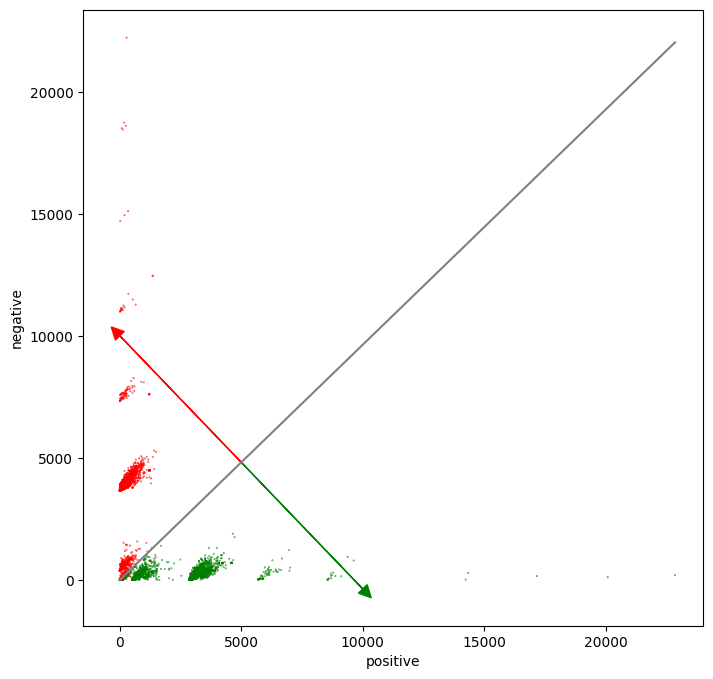

In [33]:
# plot everything 
fig, ax = plt.subplots(figsize=(8,8))
colours = ['red', 'green']

ax.scatter(X[:,1], X[:,2], c=[colours[int(k)] for k in Y], s=0.1)
plt.xlabel("positive")
plt.ylabel("negative")

maxpos = np.max(X[:,1])
offset = 5000 # pos value for direction vectors origin

ax.plot([0,maxpos], [neg(theta,0), neg(theta, maxpos)], color='gray')
ax.arrow(offset, neg(theta, offset), offset, direction(theta, offset), head_width=500, head_length=500, fc='g', ec='g')
ax.arrow(offset, neg(theta, offset), -offset, -direction(theta, offset), head_width=500, head_length=500, fc='r', ec='r')

plt.show()